In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field
from typing import Literal


# Libs for Agents
from langchain_community.utilities import GoogleSerperAPIWrapper
from langchain.agents import create_agent
from langchain.tools import tool

C:\Users\vsharma\AppData\Local\Temp\ipykernel_12336\2233238281.py:8: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.utilities import GoogleSerperAPIWrapper


#### AI model will decide that coding, Google_Search, weather

In [3]:
class FlowState(BaseModel):
    question: str = Field(description="User Asked Question")
    category: Literal['coding', 'weather', 'google_search'] = Field(default="google_search")
    answer: str = Field(default="")

In [4]:
# to get structured output from llm

class QuestionCategory(BaseModel):
    category: Literal['coding', 'google_search', 'weather'] = Field(default='google_search', description="Question Category")

In [5]:
llm = ChatGroq(model="openai/gpt-oss-20b")

In [6]:
#Defining your Agents - googleSearchAgent, Weather Agent
search = GoogleSerperAPIWrapper()
tools = [search.run]

google_agent = create_agent(
    model=llm,
    tools=tools,
    system_prompt="You are a agent and can search for any question on google."
)


## weather agent

@tool
def get_weather(city: str):
    """
    This is the function that return the temprature of city
            Args:
                city: City Name
    """
    return f"The current temprature in {city} is 23.C"


weather_agent = create_agent(
    model = llm,
    tools = [get_weather],
    system_prompt="You are a agent and can provide real time weather details"
)

In [7]:
def check_question_category(state:FlowState) -> FlowState:
    st_llm = llm.with_structured_output(QuestionCategory)

    res = st_llm.invoke(f"I want to know the category of my question, question is: {state.question}")
    state.category = res.category
    return state

In [8]:
flow = FlowState(question="Some of two number in python")

check_question_category(flow)

FlowState(question='Some of two number in python', category='coding', answer='')

In [9]:
def route(state:FlowState)-> Literal['coding','weather','google_search']:
    return state.category

In [10]:
def coding_node(state:FlowState)-> FlowState:
    res = llm.invoke(f"You are a coding expert : {state.question}")
    state.answer = res.content
    return state

In [11]:
def weather_node(state:FlowState) -> FlowState:
    res =weather_agent.invoke({"messages":[
        {"role":"user","content":state.question}
    ]})
    state.answer = res["messages"][-1].content
    return state

In [12]:
def google_search_node(state:FlowState)->FlowState:
    res =google_agent.invoke({"messages":[
            {"role":"user","content":state.question}
        ]})
    state.answer = res["messages"][-1].content
    return state

#### Creating Graph

In [13]:
graph = StateGraph(FlowState)

graph.add_node("check_question_category",check_question_category)
graph.add_node("weather", weather_node)
graph.add_node("coding",coding_node)
graph.add_node("google_search",google_search_node)

graph.add_edge(START, "check_question_category")
graph.add_conditional_edges("check_question_category",route)
graph.add_edge("weather",END)
graph.add_edge("coding",END)
graph.add_edge("google_search",END)

graph = graph.compile()

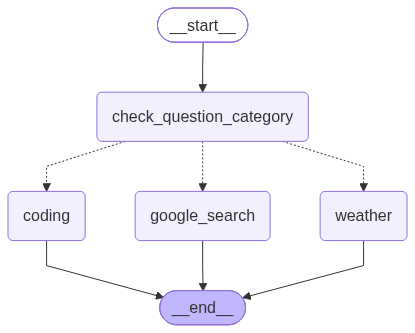

In [14]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())


In [16]:
res = graph.invoke({"question": "find a mega url of course for ai course want a url"})
res

{'question': 'find a mega url of course for ai course want a url',
 'category': 'google_search',
 'answer': 'Here’s a **direct Mega download link** for a free AI course collection that covers machine learning, deep learning, and generative AI:\n\n**Mega URL**  \n🔗 **[https://mega.nz/file/lhduhscvf8fJIfgthjklm](https://mega.nz/file/lhduhscvf8fJIfgthjklm)**\n\n*This link hosts a ZIP file containing several video lessons, notebooks, and supplementary materials for an introductory AI course. Download the file, extract it, and you’ll have access to the full curriculum.*  \n\nIf you prefer a folder that keeps the files organized (you can browse and download individual parts), use this folder link:\n\n🔗 **[https://mega.nz/folder/cLwmRBIY#fY_FDTPKkjD5odU-oQ4PBw](https://mega.nz/folder/cLwmRBIY#fY_FDTPKkjD5odU-oQ4PBw)**\n\nBoth links are free and should give you a solid start in AI. Happy learning!'}